# Day 5 Mini-Project: Titanic Survival Classification

This notebook builds a complete supervised-learning pipeline using the Titanic dataset from `week1/day4/train.csv`. The goal is to predict whether a passenger survived.

**Pipeline:** EDA → train/test split  → cross-validated model comparison → final test evaluation.

## 1. Problem definition and metric

`Survived` is binary (`0 = did not survive`, `1 = survived`), so this is a **classification** task.

The primary metric is **F1-score for the survivor class**. Accuracy alone can look acceptable when the classes are uneven, while F1 balances precision (how often predicted survivors truly survived) and recall (how many actual survivors were found). Accuracy, precision, recall, and ROC AUC are also reported for context.

A most-frequent-class dummy classifier is used as the baseline. A useful model should clearly beat it.

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load and inspect the data

The path check below makes the notebook work whether it is launched from the repository root or from this notebook's folder.

In [3]:
df = pd.read_csv("../../week1/day4/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
summary

,dtype,missing,unique
PassengerId,int64,0,891
Survived,int64,0,2
Pclass,int64,0,3
Name,str,0,891
Sex,str,0,2
Age,float64,177,88
SibSp,int64,0,7
Parch,int64,0,7
Ticket,str,0,681
Fare,float64,0,248


### Initial observations

- `Age`, `Cabin`, and `Embarked` contain missing values.
- `PassengerId`, `Name`, and `Ticket` are identifiers or high-cardinality text rather than general passenger characteristics.
- `Cabin` is also mostly missing. For this compact baseline project, these four columns are excluded.
- `Pclass` is numeric in the file but represents three categories, so it will be one-hot encoded with `Sex` and `Embarked`.
- Missing values in retained features will be imputed inside the model pipeline, using training data only.

In [5]:
df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

## 3. Exploratory data analysis

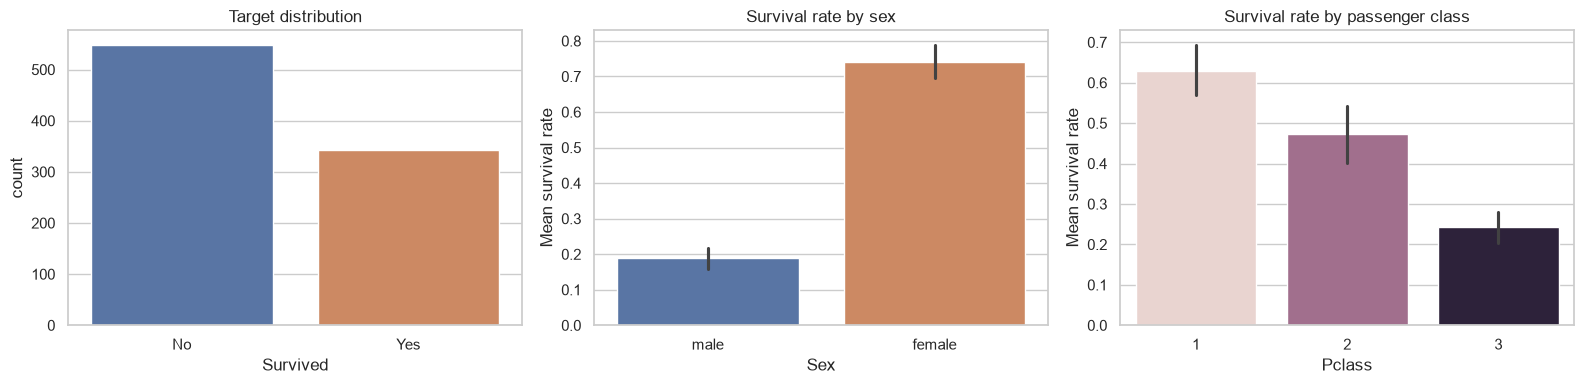

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x="Survived", hue="Survived", legend=False, ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xticks([0, 1], ["No", "Yes"])

sns.barplot(data=df, x="Sex", y="Survived", hue="Sex", legend=False, ax=axes[1])
axes[1].set_title("Survival rate by sex")
axes[1].set_ylabel("Mean survival rate")

sns.barplot(data=df, x="Pclass", y="Survived", hue="Pclass", legend=False, ax=axes[2])
axes[2].set_title("Survival rate by passenger class")
axes[2].set_ylabel("Mean survival rate")

plt.tight_layout()
plt.show()

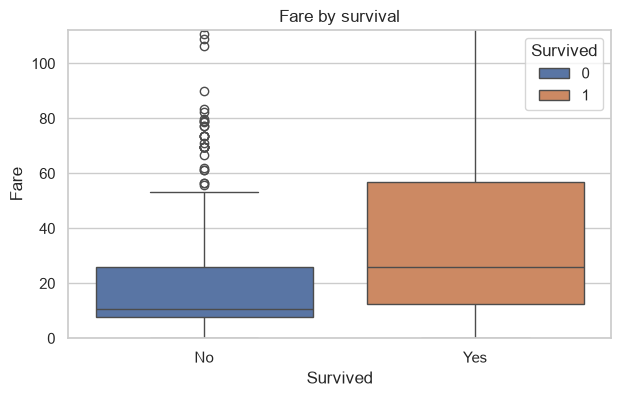

In [7]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare",
    hue="Survived",
)

plt.title("Fare by survival")
plt.xticks([0, 1], ["No", "Yes"])
plt.ylim(0, df["Fare"].quantile(0.95))

plt.show()

### EDA interpretation

The target is moderately imbalanced: non-survivors are the majority. Survival rates also differ visibly by sex and passenger class, suggesting both features will be informative. Fare is right-skewed and contains extreme values; standardization will keep numeric features on comparable scales for the linear model. These are associations, not proof of causation.

## 4. Split Before Preprocessing

The dataset was first split into training and testing sets before applying preprocessing. This helps prevent data leakage from the test set into the training process.

Missing `Age` values were filled using the mean age calculated from the training set only. Categorical features were then converted into numerical values using one-hot encoding.

Finally, the features were standardized using `StandardScaler`. The scaler was fitted only on the training data and then applied to both the training and test sets.

In [8]:
target = "Survived"

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)
age_mean = X_train["Age"].mean()

X_train["Age"] = X_train["Age"].fillna(age_mean)
X_test["Age"] = X_test["Age"].fillna(age_mean)

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

print(f"Train survival rate: {y_train.mean():.3f}")
print(f"Test survival rate:  {y_test.mean():.3f}")

Training set: (712, 10)
Test set:     (179, 10)
Train survival rate: 0.383
Test survival rate:  0.385


## 5. Compare a Baseline and Two Models

In this step, I compared three classifiers:

1. **Dummy Classifier** — used as a simple baseline that always predicts the most common class.
2. **Logistic Regression** — a simple and interpretable model for binary classification.
3. **Random Forest** — a model that can learn more complex and nonlinear relationships in the data.

To compare the models fairly, I used 5-fold stratified cross-validation on the training set. Stratification keeps the survival ratio similar in each fold.

I used the **F1 score** as the evaluation metric and compared the mean F1 score of each model. The test set was not used during model selection so it could remain untouched for the final evaluation.

In [9]:
models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(max_iter=1000),
    "Random forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )

    cv_rows.append({
        "model": name,
        "mean_cv_f1": scores.mean(),
        "std_cv_f1": scores.std()
    })

cv_results = pd.DataFrame(cv_rows)\
    .sort_values("mean_cv_f1", ascending=False)

cv_results

,model,mean_cv_f1,std_cv_f1
2,Random forest,0.745477,0.028651
1,Logistic regression,0.726037,0.034082
0,Dummy baseline,0.000000,0.000000


## 6. Final Evaluation on Unseen Test Data

All models are fitted on the full training set and evaluated once on the held-out test set.

I measured the performance using **accuracy, precision, recall, F1 score, and ROC-AUC** to get a better understanding of how each model performs.

The final model is selected based on the highest mean F1 score from the five-fold cross-validation performed on the training data. The test set is only used for final evaluation and is not used to choose the winning model.

In [10]:
fitted_models = {}
test_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    fitted_models[name] = model

    test_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
    })

test_results = pd.DataFrame(test_rows)

selected_model_name = cv_results.iloc[0]["model"]

print(f"Selected model based on CV F1: {selected_model_name}")

test_results

Selected model based on CV F1: Random forest


,model,accuracy,precision,recall,f1,roc_auc
0,Dummy baseline,0.614525,0.000000,0.000000,0.000000,0.500000
1,Logistic regression,0.804469,0.793103,0.666667,0.724409,0.843347
2,Random forest,0.804469,0.814815,0.637681,0.715447,0.838999


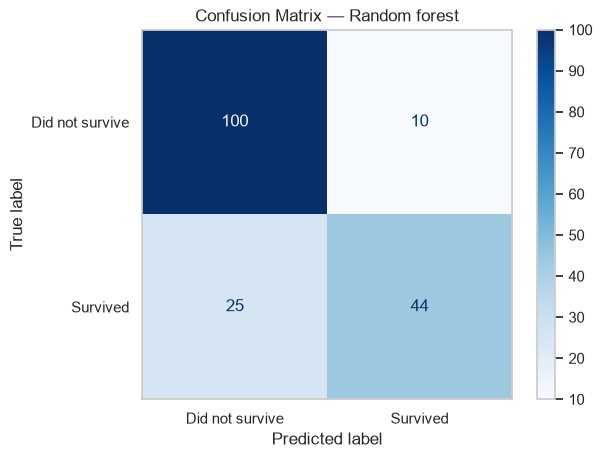

In [12]:
selected_name = cv_results.loc[
    cv_results["model"] != "Dummy baseline", "model"
].iloc[0]

selected_model = fitted_models[selected_name]

selected_predictions = selected_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    selected_predictions,
    display_labels=["Did not survive", "Survived"],
    cmap="Blues"
)

plt.title(f"Confusion Matrix — {selected_name}")
plt.grid(False)
plt.show()

## 7. Conclusion

Random forest was selected because it achieved the highest mean cross-validation F1 score on the training data: **0.745**, compared with **0.726** for logistic regression and **0.000** for the dummy baseline.

On the held-out test set, random forest achieved **0.715 F1**, **0.804 accuracy**, and **0.838 ROC AUC**, clearly outperforming the dummy baseline.

Logistic regression achieved a slightly higher test F1 of **0.724**, but the test set should not be used to change the selected model. Since random forest had already been selected using training cross-validation, it remains the final choice.

This keeps the model selection process separate from the final evaluation on unseen data.